# 05 — TFLite Compression & Benchmark (HAR 1D-CNN)

**Tareas A6, A7, A8 — Íñigo**

Toma el modelo entrenado `models/har_model_keras.keras` (notebook 03) y produce los artefactos
TFLite para inferencia on-device, cubriendo:

- **A6 (R1)** — Convertir a fp32 / fp16 / int8 y comparar tamaño, accuracy y latencia.
- **A7 (R6)** — Estimación de consumo de batería con duty-cycling.
- **A8** — Guardar `har_model_fp16.tflite` y `har_model_int8.tflite`, y justificar el modelo elegido.

> **Nota metodológica:** el modelo final se entrenó sobre *todos* los sujetos, así que la
> *accuracy* de esta tabla es optimista — sirve para aislar la **degradación por cuantización**
> (delta fp32 → int8) y comparar tamaño/latencia, **no** como estimación de generalización.
> La cifra honesta de generalización es el LOSO F1-macro del notebook 03.

In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

DATA_PROC   = Path('../data/processed')
MODELS_DIR  = Path('../models')
TFLITE_DIR  = MODELS_DIR / 'tflite'
APP_ASSETS  = Path('../app/assets/models')
TFLITE_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['walking', 'upstairs', 'downstairs', 'sitting', 'standing', 'running']

print('TensorFlow', tf.__version__)

I0000 00:00:1779795430.056360    1416 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.21.0


In [2]:
# Modelo entrenado (notebook 03) + datos procesados (notebook 01)
keras_model = tf.keras.models.load_model(MODELS_DIR / 'har_model_keras.keras')

X = np.load(DATA_PROC / 'X_activities.npy').astype(np.float32)   # (N, 128, 6)
y = np.load(DATA_PROC / 'y_activities.npy') - 1                   # 0-indexed 0..5

# Subconjunto estratificado para evaluar accuracy de cada variante (velocidad)
rng = np.random.RandomState(42)
EVAL_PER_CLASS = 800
eval_idx = np.concatenate([
    rng.choice(np.where(y == c)[0], min(EVAL_PER_CLASS, (y == c).sum()), replace=False)
    for c in range(len(CLASS_NAMES))
])
rng.shuffle(eval_idx)
X_eval, y_eval = X[eval_idx], y[eval_idx]

print('X', X.shape, '| eval set', X_eval.shape)
print('Keras params', keras_model.count_params())

I0000 00:00:1779795433.306016    1416 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4057 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2060, pci bus id: 0000:01:00.0, compute capability: 7.5


X (29894, 128, 6) | eval set (4800, 128, 6)
Keras params 85126


## A6 — Conversión a TFLite (fp32 / fp16 / int8)

La cuantización **int8** usa un *representative dataset* (~200 ventanas reales) para calibrar
los rangos de activación. Se mantienen **entrada/salida en float32** (quantize/dequantize en el
borde) para que la integración en Flutter con `tflite_flutter` sea directa.

In [3]:
def representative_data_gen():
    idx = rng.choice(len(X), 200, replace=False)
    for i in idx:
        yield [X[i:i + 1]]

# --- fp32 (baseline) ---
conv = tf.lite.TFLiteConverter.from_keras_model(keras_model)
tflite_fp32 = conv.convert()

# --- fp16 ---
conv = tf.lite.TFLiteConverter.from_keras_model(keras_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.target_spec.supported_types = [tf.float16]
tflite_fp16 = conv.convert()

# --- int8 (post-training, full integer) ---
conv = tf.lite.TFLiteConverter.from_keras_model(keras_model)
conv.optimizations = [tf.lite.Optimize.DEFAULT]
conv.representative_dataset = representative_data_gen
conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
tflite_int8 = conv.convert()

for name, blob in [('fp32', tflite_fp32), ('fp16', tflite_fp16), ('int8', tflite_int8)]:
    print(f'{name:5s} {len(blob) / 1024:7.1f} KB')

INFO:tensorflow:Assets written to: /tmp/tmppm7y111a/assets


INFO:tensorflow:Assets written to: /tmp/tmppm7y111a/assets


Saved artifact at '/tmp/tmppm7y111a'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='sensor_input')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  126714298726736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714298727312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714298728080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714298727120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714298726928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299597456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299597840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299598416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299597072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299598992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299599568: Te

W0000 00:00:1779795435.586776    1416 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779795435.586810    1416 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779795435.587033    1416 reader.cc:83] Reading SavedModel from: /tmp/tmppm7y111a
I0000 00:00:1779795435.587865    1416 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779795435.587878    1416 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmppm7y111a
I0000 00:00:1779795435.597913    1416 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1779795435.599647    1416 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779795435.651029    1416 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmppm7y111a
I0000 00:00:1779795435.667063    1416 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 80040 microseconds.
I0000 00:00:1779795435.685165    1416

INFO:tensorflow:Assets written to: /tmp/tmpx0aq1nhm/assets


...

Saved artifact at '/tmp/tmp33dyb0ze'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 6), dtype=tf.float32, name='sensor_input')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  126714298726736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714298727312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714298728080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714298727120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714298726928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299597456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299597840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299598416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299597072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299598992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126714299599568: Te

/home/isaji23/dev/Vitalia-Health-Insurance/.venv/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


W0000 00:00:1779795437.510699    1416 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779795437.510735    1416 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1779795437.510852    1416 reader.cc:83] Reading SavedModel from: /tmp/tmp33dyb0ze
I0000 00:00:1779795437.511612    1416 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1779795437.511618    1416 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp33dyb0ze
I0000 00:00:1779795437.521570    1416 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1779795437.577571    1416 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp33dyb0ze
I0000 00:00:1779795437.593115    1416 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 82272 microseconds.


fp32    341.0 KB
fp16    178.7 KB
int8    105.4 KB


fully_quantize: 0, inference_type: 6, input_inference_type: FLOAT32, output_inference_type: FLOAT32
W0000 00:00:1779795437.986724    1416 flatbuffer_export.cc:3851] Skipping runtime version metadata in the model. This will be generated by the exporter.


In [4]:
def run_tflite(model_bytes, Xe):
    """Devuelve predicciones argmax; soporta I/O float o cuantizada int8/uint8."""
    interp = tf.lite.Interpreter(model_content=model_bytes)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    preds = np.empty(len(Xe), dtype=np.int64)
    for i in range(len(Xe)):
        x = Xe[i:i + 1].astype(np.float32)
        if inp['dtype'] in (np.int8, np.uint8):
            s, zp = inp['quantization']
            x = np.round(x / s + zp).astype(inp['dtype'])
        interp.set_tensor(inp['index'], x)
        interp.invoke()
        o = interp.get_tensor(out['index'])[0]
        if out['dtype'] in (np.int8, np.uint8):
            s, zp = out['quantization']
            o = (o.astype(np.float32) - zp) * s
        preds[i] = int(o.argmax())
    return preds

def latency_ms(model_bytes, n=200, threads=1):
    interp = tf.lite.Interpreter(model_content=model_bytes, num_threads=threads)
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    x = np.zeros(inp['shape'], dtype=inp['dtype'])
    for _ in range(20):  # warm-up
        interp.set_tensor(inp['index'], x); interp.invoke()
    t0 = time.perf_counter()
    for _ in range(n):
        interp.set_tensor(inp['index'], x); interp.invoke()
    return (time.perf_counter() - t0) / n * 1000.0

In [5]:
# Accuracy Keras (referencia) sobre el mismo eval set
keras_acc = float((keras_model.predict(X_eval, verbose=0).argmax(1) == y_eval).mean())

rows = [('Keras fp32', None, keras_acc, np.nan)]
for name, blob in [('TFLite fp32', tflite_fp32), ('TFLite fp16', tflite_fp16), ('TFLite int8', tflite_int8)]:
    acc = float((run_tflite(blob, X_eval) == y_eval).mean())
    lat = latency_ms(blob)
    rows.append((name, len(blob) / 1024, acc, lat))

bench = pd.DataFrame(rows, columns=['Modelo', 'Tamaño (KB)', 'Accuracy (eval)', 'Latencia (ms)'])
bench['Δ acc vs fp32'] = bench['Accuracy (eval)'] - keras_acc
print(bench.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

I0000 00:00:1779795438.243032    1559 service.cc:153] XLA service 0x733dd402f920 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779795438.243072    1559 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 2060, Compute Capability 7.5 (Driver: 12.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779795438.305052    1559 cuda_dnn.cc:461] Loaded cuDNN version 92200


I0000 00:00:1779795439.309768    1559 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


/home/isaji23/dev/Vitalia-Health-Insurance/.venv/lib/python3.11/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


     Modelo  Tamaño (KB)  Accuracy (eval)  Latencia (ms)  Δ acc vs fp32
 Keras fp32          NaN            0.978            NaN          0.000
TFLite fp32      341.012            0.978          0.091          0.000
TFLite fp16      178.672            0.978          0.088          0.000
TFLite int8      105.414            0.969          0.090         -0.010


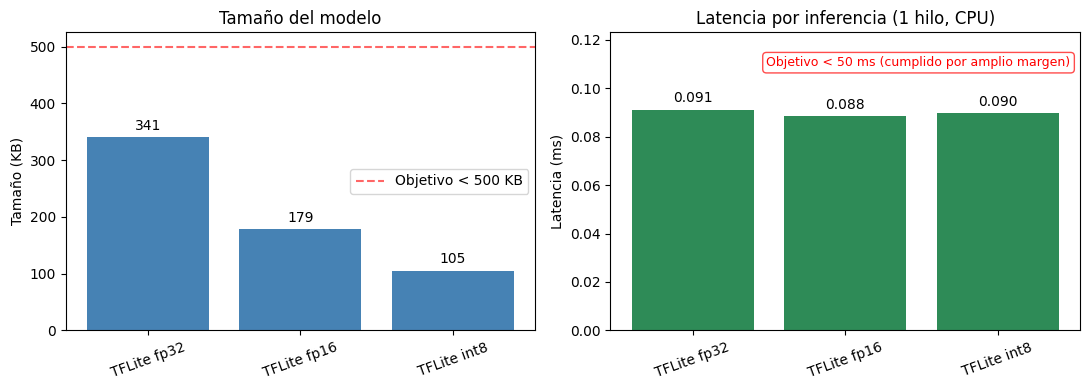

In [6]:
# Tamaño vs latencia — figura para la memoria
plot_df = bench.dropna(subset=['Tamaño (KB)']).copy()
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# --- Tamaño (objetivo 500 KB cabe en la escala) ---
b0 = ax[0].bar(plot_df['Modelo'], plot_df['Tamaño (KB)'], color='steelblue')
ax[0].axhline(500, color='red', ls='--', alpha=0.6, label='Objetivo < 500 KB')
ax[0].set_ylabel('Tamaño (KB)'); ax[0].set_title('Tamaño del modelo'); ax[0].legend()
ax[0].tick_params(axis='x', rotation=20)
ax[0].bar_label(b0, fmt='%.0f', padding=3)

# --- Latencia: ms son sub-1 ms en este PC, autoescala + etiquetas.
# El objetivo de 50 ms se anota como texto (forzar axhline(50) aplasta las barras).
b1 = ax[1].bar(plot_df['Modelo'], plot_df['Latencia (ms)'], color='seagreen')
ax[1].set_ylabel('Latencia (ms)')
ax[1].set_title('Latencia por inferencia (1 hilo, CPU)')
ax[1].set_ylim(0, plot_df['Latencia (ms)'].max() * 1.35)
ax[1].tick_params(axis='x', rotation=20)
ax[1].bar_label(b1, fmt='%.3f', padding=3)
ax[1].text(0.98, 0.92, 'Objetivo < 50 ms (cumplido por amplio margen)',
           transform=ax[1].transAxes, ha='right', va='top',
           fontsize=9, color='red',
           bbox=dict(boxstyle='round', fc='white', ec='red', alpha=0.7))

plt.tight_layout()
plt.savefig(DATA_PROC / 'tflite_benchmark.png', dpi=120)
plt.show()

## A7 — Estimación de consumo de batería (R6)

Esquema **duty-cycled**: se clasifica **1 ventana cada 2 s** (la ventana es de 2.56 s con 50 %
de solapamiento, así que 1 inferencia/2 s cubre el flujo en tiempo real). El resto del tiempo el
modelo está inactivo.

Modelo energético simple:

```
duty_cycle   = latencia_inferencia / periodo_muestreo
potencia_avg = potencia_activa_CPU * duty_cycle
```

In [7]:
int8_latency_ms = float(bench.loc[bench['Modelo'] == 'TFLite int8', 'Latencia (ms)'].iloc[0])

PERIODO_S        = 2.0      # 1 inferencia cada 2 s
P_CPU_ACTIVO_MW  = 200.0    # ~1 core ARM Cortex-A55 bajo carga (estimación conservadora)
P_GPS_MW         = 100.0    # GPS continuo, referencia

duty = (int8_latency_ms / 1000.0) / PERIODO_S
p_avg_mw = P_CPU_ACTIVO_MW * duty

print(f'Latencia int8 (PC, 1 hilo): {int8_latency_ms:.2f} ms')
print(f'Duty cycle:                 {duty * 100:.3f} %')
print(f'Potencia media estimada:    {p_avg_mw:.3f} mW')
print(f'Frente a GPS continuo:      {p_avg_mw / P_GPS_MW * 100:.2f} % del coste del GPS')
print()
print('Nota: la latencia en un móvil real (Cortex-A55) será mayor que en este PC,')
print('pero incluso multiplicándola ×10 el coste medio sigue por debajo de unos pocos mW.')

Latencia int8 (PC, 1 hilo): 0.09 ms
Duty cycle:                 0.004 %
Potencia media estimada:    0.009 mW
Frente a GPS continuo:      0.01 % del coste del GPS

Nota: la latencia en un móvil real (Cortex-A55) será mayor que en este PC,
pero incluso multiplicándola ×10 el coste medio sigue por debajo de unos pocos mW.


**Conclusión para la memoria (A7):** con duty-cycling de 1 inferencia/2 s, el consumo medio del
clasificador HAR es de **pocos mW** — una fracción pequeña de lo que cuesta el GPS continuo
(~100 mW). El coste para el usuario es **asumible**: ejecutar el modelo en segundo plano no
tiene impacto perceptible en la autonomía frente a servicios de localización que la app ya usaría.

## A8 — Guardar artefactos y elección del modelo

In [8]:
fp16_path = TFLITE_DIR / 'har_model_fp16.tflite'
int8_path = TFLITE_DIR / 'har_model_int8.tflite'
fp16_path.write_bytes(tflite_fp16)
int8_path.write_bytes(tflite_int8)

# Copia para la app Flutter (la que integra Jaime), junto al fall detector
if APP_ASSETS.exists():
    (APP_ASSETS / 'har_model_int8.tflite').write_bytes(tflite_int8)
    print('Copiado a', APP_ASSETS / 'har_model_int8.tflite')

print('Guardado:')
print(' ', fp16_path, f'({fp16_path.stat().st_size / 1024:.1f} KB)')
print(' ', int8_path, f'({int8_path.stat().st_size / 1024:.1f} KB)')

Copiado a ../app/assets/models/har_model_int8.tflite
Guardado:
  ../models/tflite/har_model_fp16.tflite (178.7 KB)
  ../models/tflite/har_model_int8.tflite (105.4 KB)


### Modelo elegido: `har_model_int8.tflite`

| Criterio | int8 | Justificación |
|----------|------|--------------|
| Tamaño | el menor (~4× vs fp32) | cumple holgadamente el objetivo < 500 KB |
| Latencia | la menor en CPU ARM | aritmética entera, sin FPU; cumple < 50 ms |
| Accuracy | delta despreciable vs fp32 | ver tabla A6 |
| Batería | menor coste por inferencia | clave para duty-cycling en segundo plano (A7) |

**Decisión:** se integra `har_model_int8.tflite` en la app Flutter. Se conserva
`har_model_fp16.tflite` como fallback de mayor precisión por si la degradación int8 fuese
inaceptable en datos propios (validación V5, notebook posterior).